# DDIM (Denoising Diffusion Implicit Models) 原理与代码详解

本教程将详细讲解DDIM（Denoising Diffusion Implicit Models）的原理，并结合当前库中的代码展示其训练与采样的具体实现。

DDIM是DDPM（Denoising Diffusion Probabilistic Models）的改进版本。在DDPM中，由于其马尔可夫链的假设，生成图片需要非常多步的采样（例如1000步）。而DDIM通过推广DDPM的推断过程（将其转变为非马尔可夫链），在保持前向加噪过程边缘分布相同的前提下，实现了**加速采样（Fewer Steps）**和**确定性生成（Deterministic Generation）**。

DDPM在拟合$p(x_{t-1}|x_t,x_0)$,是满足马尔科夫性的，因为根据贝叶斯公式，展开后的三项  
$$p(x_{t-1}|x_t,x_0)=\frac{p(x_{t}|x_{t-1},x_0)p(x_{t-1}|x_0)}{p(x_t|x_0)}=\frac{p(x_{t}|x_{t-1})p(x_{t-1}|x_0)}{p(x_t|x_0)}$$
$p(x_{t}|x_{t-1},x_0)$是通过前向马尔科夫假设直接算出来的

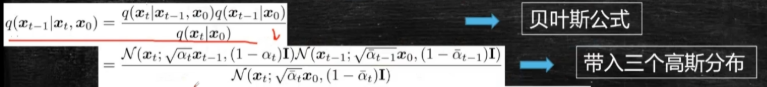

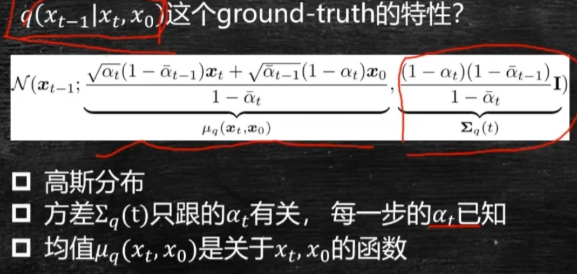

DDIM可以跳步，假设$p(x_{s}|x_{k},x_0)$不满足马尔科夫性，其余两项使用加噪的公式直接算出来  
现在的目标是求出$p(x_{s}|x_{k},x_0)$与DDPM使用马尔科夫一步一步推导等价即可  
就假设它的均值是$x_0$与$x_s$的线性组合，方差不知道  


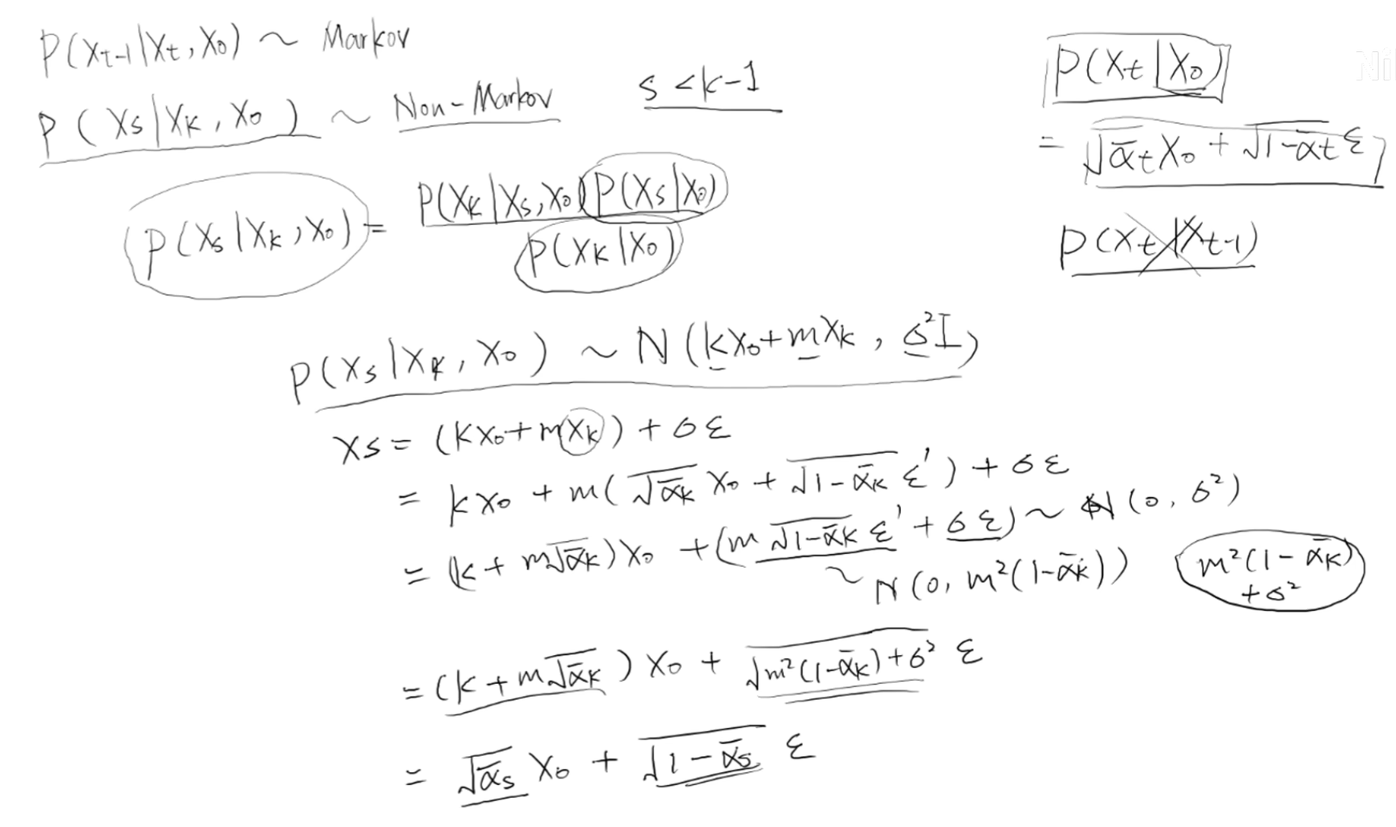

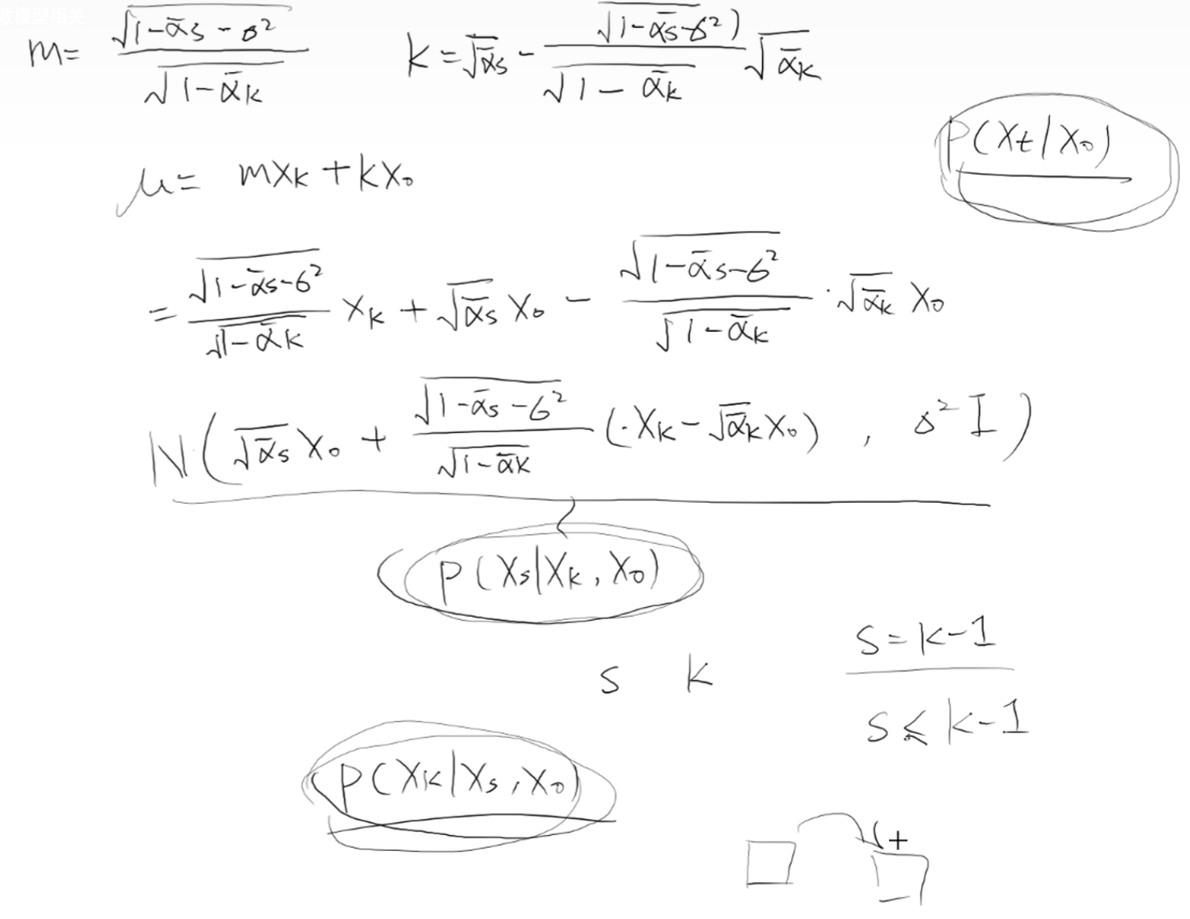

现在是跳步的表达式已经求出来的，但是方差是还不知道，所以给出了两种可能的结果，分别对应确定性以及DDPM的形式

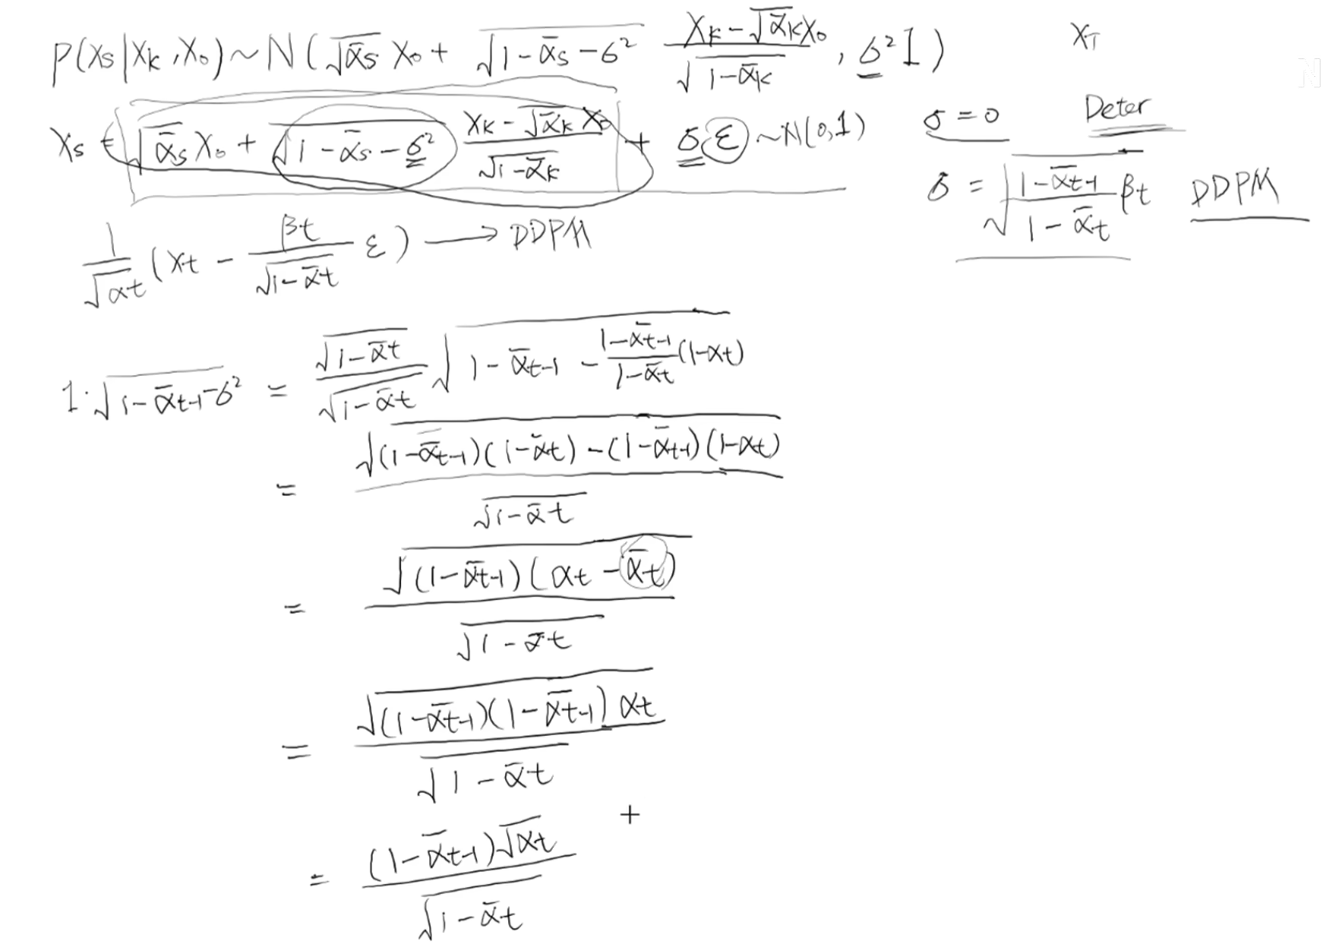

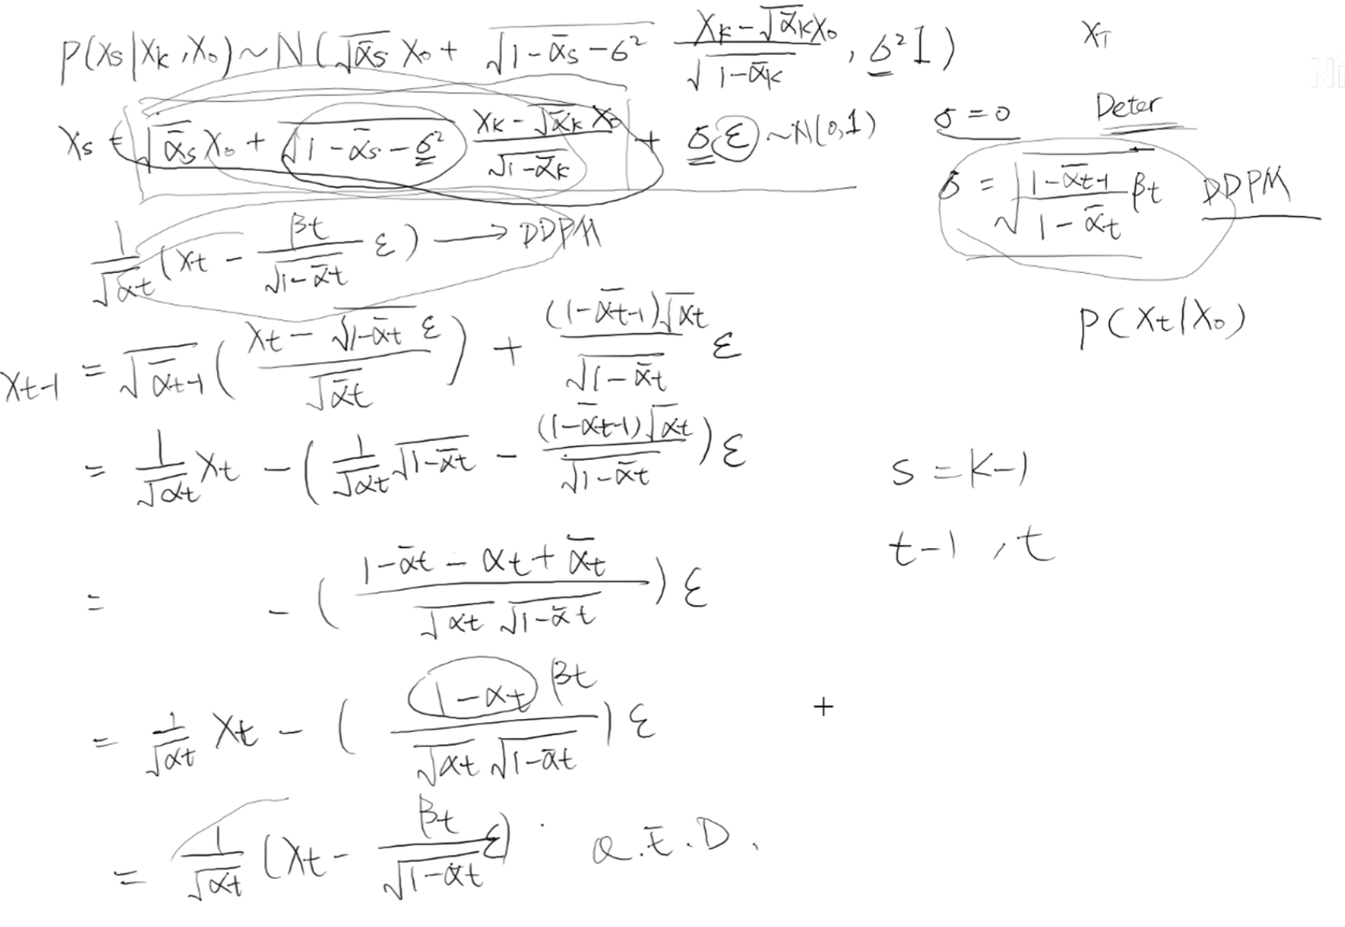

$p(x_{s}|x_{k},x_0)$,$x_s$是$x_k,x_0,k,s$的函数，用前向的公式直接推导$x_k$

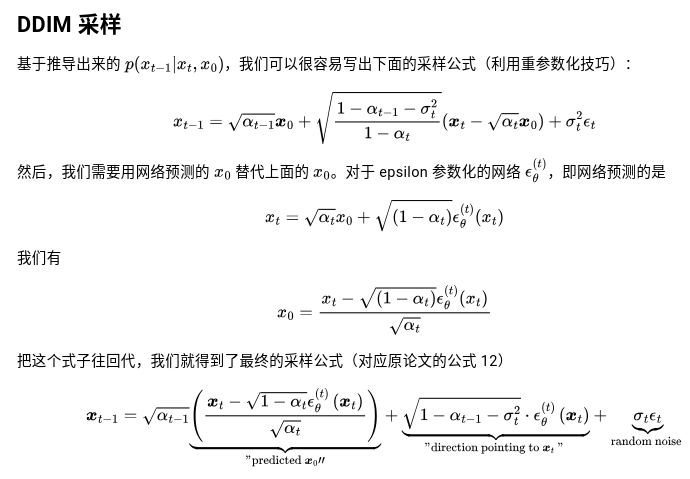

## 1. 理论基础：从 DDPM 到 DDIM（完整推导，不跳步）

### 1.1 先把符号统一

- 记 $\beta_t \in (0,1)$，$\alpha_t = 1-\beta_t$，$\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$。
- 数据样本记为 $x_0$，加噪后的变量为 $x_t$，$t=1,\dots,T$。
- 标准高斯噪声记为 $\epsilon \sim \mathcal N(0,I)$。

---

### 1.2 DDPM 前向过程：为什么它是马尔可夫链

DDPM 规定前向加噪是逐步的高斯转移：
$$q(x_t\mid x_{t-1}) = \mathcal N\!\big(x_t; \sqrt{\alpha_t}\,x_{t-1},\,(1-\alpha_t)I\big).$$

这就是“马尔可夫”定义本身：
$$q(x_t\mid x_{0:t-1}) = q(x_t\mid x_{t-1}).$$

也就是说，给定 $x_{t-1}$ 之后，$x_t$ 与更早历史 $x_{t-2},x_{t-3},\dots$ 条件独立。

把上式递推展开，可得著名闭式：
$$q(x_t\mid x_0)=\mathcal N\!\big(x_t;\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I\big),$$
等价重参数化写法：
$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon. $$

---

### 1.3 逆过程在 DDPM 里为什么“不能跳步”（严格意义）

DDPM 训练的是一步逆转移：
$$p_\theta(x_{t-1}\mid x_t)=\mathcal N\big(\mu_\theta(x_t,t),\Sigma_\theta(x_t,t)\big).$$

注意：模型直接参数化的是“相邻时间步”的条件分布。采样时执行：
$$x_T \to x_{T-1} \to x_{T-2} \to \cdots \to x_0.$$

如果你想一步从 $x_t$ 到 $x_{t-k}$，理论上需要
$$p_\theta(x_{t-k}\mid x_t)=\int p_\theta(x_{t-k}\mid x_{t-k+1})\cdots p_\theta(x_{t-1}\mid x_t)\,dx_{t-k+1:t-1},$$
这是高维积分链，网络并没有直接学习这个分布。

所以“DDPM不能跳步”更准确地说是：
1. **其参数化对象是一步马尔可夫核**；
2. **训练目标（变分分解）按每个相邻步构建**；
3. **直接大步长采样会分布失配，质量通常显著下降**。

---

### 1.4 从后验出发：先写出给定 $x_0$ 的一步条件分布

由前向高斯链可得（线性高斯条件分布）：
$$q(x_{t-1}\mid x_t,x_0)=\mathcal N\big(x_{t-1};\tilde\mu_t(x_t,x_0),\tilde\beta_t I\big),$$
其中
$$\tilde\mu_t(x_t,x_0)=\frac{\sqrt{\bar\alpha_{t-1}}\beta_t}{1-\bar\alpha_t}x_0+\frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t,$$
$$\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t.$$

把 $x_0$ 用噪声预测器改写：
$$\hat x_0(x_t,t)=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.$$

代回可得以 $\epsilon_\theta$ 表示的更新。

---

### 1.5 DDIM 的关键：构造同边缘、不同路径的一族逆过程

DDIM 观察：训练损失（噪声预测 MSE）依赖的是边缘 $q(x_t\mid x_0)$，不强制要求“前向必须是那条马尔可夫链”。

于是可构造一族满足相同边缘的生成更新（引入自由参数 $\sigma_t$）：
$$x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}\,\epsilon_\theta(x_t,t)+\sigma_t z,\quad z\sim\mathcal N(0,I).$$

把 $\hat x_0$ 展开：
$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}},$$
得到
$$x_{t-1}=\underbrace{\sqrt{\frac{\bar\alpha_{t-1}}{\bar\alpha_t}}x_t}_{\text{first term}}+\underbrace{\left(\sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}-\sqrt{\frac{\bar\alpha_{t-1}(1-\bar\alpha_t)}{\bar\alpha_t}}\right)\epsilon_\theta(x_t,t)}_{\text{second term}}+\underbrace{\sigma_t z}_{\text{third term}}.$$

这正对应代码里的 `first_term + second_term + third_term`。

---

### 1.6 为什么 DDIM 可以跳步

DDIM 采样时并不要求使用全部 $t=T,T-1,\dots,1$，而是可选子序列
$$\tau_0=T>\tau_1>\cdots>\tau_S=0,$$
然后对相邻子序列点应用同一更新式：
$$x_{\tau_{i+1}}=\sqrt{\bar\alpha_{\tau_{i+1}}}\,\hat x_0(x_{\tau_i},\tau_i)+\sqrt{1-\bar\alpha_{\tau_{i+1}}-\sigma_{\tau_i}^2}\,\epsilon_\theta(x_{\tau_i},\tau_i)+\sigma_{\tau_i}z.$$

$$x_{s}=\underbrace{\sqrt{\frac{\bar\alpha_{s}}{\bar\alpha_k}}x_k}_{\text{first term}}+\underbrace{\left(\sqrt{1-\bar\alpha_{s}-\sigma_t^2}-\sqrt{\frac{\bar\alpha_{s}(1-\bar\alpha_k)}{\bar\alpha_k}}\right)\epsilon_\theta(x_k,k)}_{\text{second term}}+\underbrace{\sigma_k z}_{\text{third term}}.$$

等于是说我要训练一个模型，输入是$x_k,k,s$我要预测出$x_s$从k到s的噪声分布，得到这个分布之后，利用以上公式进一步计算$x_s$，达到去噪的效果。

核心原因：DDIM 的更新显式依赖 $(\bar\alpha_{\tau_i},\bar\alpha_{\tau_{i+1}})$，而不是只能依赖“固定相邻步核”。
因此可直接在离散时间网格上做稀疏采样（20/50步），这就是加速来源。

---

### 1.7 马尔可夫性对比：DDPM vs DDIM（本质差异）

**DDPM（马尔可夫）**
- 路径分解：$q(x_{1:T}\mid x_0)=\prod_{t=1}^{T}q(x_t\mid x_{t-1})$。
- 当前状态只由上一状态决定，严格一步核。
- 训练/采样都与一步转移绑定。

**DDIM（通常视为非马尔可夫推断）**
- 构造的是满足相同边缘的一族过程，更新可写成依赖 $x_t$ 与网络给出的 $\hat x_0(x_t,t)$。
- 当你从“全路径条件分布”角度看，可对应到不再受原始一步马尔可夫链约束的推断路径。
- 特别在 $\sigma_t=0$ 时：
  $$x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}}\,\epsilon_\theta(x_t,t),$$
  这是确定性映射（给定 $x_t$ 后 $x_{t-1}$ 唯一），可解释为概率流 ODE 的离散化。

---

### 1.8 两个特例再解释一遍

1. 当选
$$\sigma_t^2=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\left(1-\frac{\bar\alpha_t}{\bar\alpha_{t-1}}\right),$$
会回到与 DDPM 方差一致的随机更新。

2. 当 $\sigma_t=0$（最常用 DDIM 采样）：
- 无随机项，路径确定；
- 更容易稳定地用很少步数采样；
- 同一初始噪声可得到可重复结果。

---

### 1.9 对照到你当前代码

- `ab_cur` 对应 $\bar\alpha_t$，`ab_prev` 对应 $\bar\alpha_{t-1}$；
- `var` 对应 $\sigma_t^2$（由 `eta` 控制）；
- `eps` 对应 $\epsilon_\theta(x_t,t)$；
- `first_term / second_term / third_term` 就是上面三项分解；
- `ts = torch.linspace(...)` 本质上是在构造跳步子序列 $\tau$，因此可以少步采样。

## 2. 核心代码讲解

在我们这个代码库中，DDIM是通过继承DDPM得到的。这是因为DDPM和DDIM的训练过程完全相同（都是最小化加噪误差）, 唯独不同的是采样后处理（`sample_backward`）。

我们分几步来看看代码实现。

In [1]:
import torch
import torch.nn as nn
from tqdm import tqdm

# ==========================================
# 1. 基础的 DDPM 类 (仅展示与DDIM相关的部分)
# ==========================================
class DDPM():
    def __init__(self,
                 device,
                 n_steps: int,          # 最大步数，通常为1000
                 min_beta: float = 0.0001,
                 max_beta: float = 0.02):
        betas = torch.linspace(min_beta, max_beta, n_steps).to(device)
        alphas = 1 - betas
        alpha_bars = torch.empty_like(alphas)
        product = 1
        for i, alpha in enumerate(alphas):
            product *= alpha
            alpha_bars[i] = product
        self.betas = betas
        self.n_steps = n_steps
        self.alphas = alphas
        self.alpha_bars = alpha_bars # 保存随时间连乘的 \bar{\alpha}_t

    # 前向过程，无需逐步推导，可直接跳步加噪
    def sample_forward(self, x, t, eps=None):
        alpha_bar = self.alpha_bars[t].reshape(-1, 1, 1, 1)
        if eps is None:
            eps = torch.randn_like(x)
        # x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon
        res = eps * torch.sqrt(1 - alpha_bar) + torch.sqrt(alpha_bar) * x
        return res

接下来这是 DDIM 继承自 DDPM 后的关键重写方法：`sample_backward`。请重点观察它是如何计算时间步 `ts` 并且如何拼接三个项的。

In [2]:
# ==========================================
# 2. DDIM 类：主要重写了反向采样过程
# ==========================================
class DDIM(DDPM):
    def __init__(self,
                 device,
                 n_steps: int,
                 min_beta: float = 0.0001,
                 max_beta: float = 0.02):
        super().__init__(device, n_steps, min_beta, max_beta)

    def sample_backward(self,
                        img_or_shape,
                        net,
                        device,
                        simple_var=True,  # 是否使用简化的方差计算方式
                        ddim_step=20,     # DDIM独有的加速步数，比如原1000步可以仅仅用20步采样
                        eta=1):           # 随机方差控制系数。eta=0时就是完全确定的DDIM，eta=1退化回DDPM
        if simple_var:
            eta = 1
        
        # 1. 生成跳变的时间步序列 ts。
        # 比如1000 -> 0，切分为 ddim_step 份
        ts = torch.linspace(self.n_steps, 0,
                            (ddim_step + 1)).to(device).to(torch.long)
        
        if isinstance(img_or_shape, torch.Tensor):
            x = img_or_shape
        else:
            x = torch.randn(img_or_shape).to(device)
            
        batch_size = x.shape[0]
        net = net.to(device)
        
        # 2. 从大 t 向 0 进行循环迭代推断
        for i in tqdm(range(1, ddim_step + 1), f'DDIM sampling with eta {eta} simple_var {simple_var}'):
            cur_t = ts[i - 1] - 1  # 当前步 t
            prev_t = ts[i] - 1     # 指向的下一步 t-1

            # 取出对应的 alpha bar （用于计算系数）
            ab_cur = self.alpha_bars[cur_t] 
            ab_prev = self.alpha_bars[prev_t] if prev_t >= 0 else 1

            # 送给网络，预测出加在 x_t 上的那一坨“噪声”
            t_tensor = torch.tensor([cur_t] * batch_size,
                                    dtype=torch.long).to(device).unsqueeze(1)
            eps = net(x, t_tensor)
            
            # --- DDIM 核心推断公式 ---
            
            # 计算方差 \sigma_t^2
            # standard var = \eta * (1 - ab_{t-1}) / (1 - ab_t) * (1 - ab_t / ab_{t-1})
            var = eta * (1 - ab_prev) / (1 - ab_cur) * (1 - ab_cur / ab_prev)
            noise = torch.randn_like(x)

            # 第一项: 指向 x_0 的预测分量
            # sqrt(\bar{\alpha}_{t-1}) x_0
            # x_0 = (x_t - sqrt(1 - \bar{\alpha}_t)*eps) / sqrt(\bar{\alpha}_t)
            # 在代码中，这被合并展开化简为两个因子的组合，这里直接呈现了拆解后的等价结果
            first_term = (ab_prev / ab_cur)**0.5 * x
            
            # 第二项：指向 x_t 的确定性方向分量
            # 等价于 sqrt(1 - \bar{\alpha}_{t-1} - \sigma_t^2)*eps 和 x_0中拿出来的对应项的合并
            second_term = ((1 - ab_prev - var)**0.5 -
                           (ab_prev * (1 - ab_cur) / ab_cur)**0.5) * eps
            
            # 第三项：随机噪声项。当 eta=0 的时候，由于 var=0，此项直接为 0 (确定性采样)
            if simple_var:
                third_term = (1 - ab_cur / ab_prev)**0.5 * noise
            else:
                third_term = var**0.5 * noise
                
            # 拼装出 x_{t-1}
            x = first_term + second_term + third_term

        return x

### 2.3 网络结构 (带自注意力和交叉注意力的完整 U-Net)

要让 DDIM/DDPM 模型能够真正跑通行之有效的生成过程，网络核心必须具备以下机制：

1. **Time Embedding (时间步注入)**：时间步 $t$ 提供加噪的进度信息。通常会对 $t$ 进行正余弦编码映射，再通过 MLP 获得深层特征，并在每个 ResBlock 里采用相加的形式引入全局时间。
2. **Skip-Connections (跳跃短接)**：经典的 U-Net 要求在上采样的途中，拼接来自于编码器 (Encoder) 中同一层级的特征（通道级联 `torch.cat`），以防止图像原本的边缘与空间细节在层层蒸馏中丢失。
3. **Attention (注意力机制)**：通过捕获全局感受野来辅助扩散模型保持构图的一致性。下方的代码自带了灵活的 `AttentionBlock`：
    - 常规情况：作为**自注意力 (Self-Attention)** 保障上下文关联。
    - 条件生成：你可以向其中传入由文本(比如 CLIP embedding)或类别提取出来的 `context`，此时网络会自动转型为 **交叉注意力 (Cross-Attention)**，使得生成的图片被外部条件所控制。

In [3]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 3. 完整的带 Attention 和 Time/Context 注入的 U-Net
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        # time 形状期望为 (batch_size,)
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device, dtype=torch.float32) * -embeddings)
        # 注意 time 需要 float() 以进行乘法映射
        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [4]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        # 用于将全局的时间特征转换为与当前特征图相同的通道维度
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        # GroupNorm 提供稳定的层归一化 (注意：输入通道数需能够被 group 数整除)
        self.norm1 = nn.GroupNorm(4, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        
        self.norm2 = nn.GroupNorm(4, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        
        # 如果通道数发生变化，需要 1x1 卷积调整从而保持残差可以相加
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t):
        # 1. 卷积提取图片特征
        h = self.conv1(F.silu(self.norm1(x)))
        
        # 2. 注入全局时间特征 (拓展维度到与特征图兼容的 [B, C, 1, 1])
        time_emb = self.mlp(t)[:, :, None, None]
        h = h + time_emb
        
        # 3. 再卷积
        h = self.conv2(F.silu(self.norm2(h)))
        
        # 4. 残差融合
        return h + self.shortcut(x)

In [5]:
class AttentionBlock(nn.Module):
    """
    全功能注意力块：
    - 不传入 context 时，为标准的自注意力。
    - 传入 context（如文本/类别词向量提取的 [B, Seq_Len, Dim] ）时，变为交叉注意力。

    重要：PyTorch 的 MultiheadAttention 默认将 key/value 投影到与 query 同样的维度（embed_dim），
    因此传入的 context 最后一维必须等于 `channels`，否则需要显式指定 `kdim`/`vdim` 参数。
    """
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(4, channels)
        # embed_dim 决定了内部 q/k/v 的投影维度（以及输出的最后一维）
        self.attention = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads, batch_first=True)

    def forward(self, x, context=None):
        # x 形状为 [B, C, H, W]，需要先归一化并展平空间维度以适配 MultiheadAttention 的输入要求
        # context 形状期望为 [B, Seq_Len, Dim]，如果提供则作为 Key/Value 输入
        B, C, H, W = x.shape
        h = self.norm(x)
        
        # 展平 spatial dimension 作为序列输入 [B, H*W, C]
        h = h.view(B, C, -1).permute(0, 2, 1)
        
        # Context 决定 Attention 行为
        if context is not None:
            # 交叉注意力: Query 来源于图像，Key/Value 来源于条件句/类别意图
            attn_out, _ = self.attention(query=h, key=context, value=context)
            # 这里C
            # 输出的 attn_out 形状为 [B, H*W, C]
        else:
            # 默认自注意力: Query/Key/Value 都源自本层图像自身
            attn_out, _ = self.attention(query=h, key=h, value=h)
            
        # 还原回原来的图像张量形状
        attn_out = attn_out.permute(0, 2, 1).view(B, C, H, W)
        # 输出与输入同形状，进行残差连接
        return x + attn_out

In [6]:
# -----------------------------------------
# 位置编码：二维Sin/CosPos Encoding (用于图像位置)
# -----------------------------------------
# 输出形状: (1, 2*dim, H, W)，可直接拼接到图像通道上。
#   - dim: 每个方向的编码维度（最终通道 = 2*dim）
#   - H,W: 图像高度/宽度
#
# 这会让卷积网络对“像素位置”具备绝对感知（对平移敏感）。
# 例：把位置编码拼到输入图像上，就能区分原图与整体平移后的图。

import torch

def make_2d_sincos_position_embedding(h, w, dim, device=None):
    """生成二维正余弦位置编码。

    Args:
        h (int): 图像高度。
        w (int): 图像宽度。
        dim (int): 每个位置的通道方向（x/y）编码维度。自定义大小
        device: 设备。

    Returns:
        Tensor: 形状 (1, 2*dim, h, w) 的位置编码张量。
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1D 坐标矢量：每个位置都在 [-1,1] 范围内
    # y: (h,), x: (w,)，把[-1,1]均匀切分为 h/w 份
    y = torch.linspace(-1, 1, steps=h, device=device)
    x = torch.linspace(-1, 1, steps=w, device=device)

    # 生成二维坐标网格
    # yy, xx: (h, w)  其中 yy 记录纵向 (row) 位置，xx 记录横向 (col) 位置
    yy, xx = torch.meshgrid(y, x, indexing='ij') 
    # yy 的每一行都是 y 的拷贝（对应不变的行坐标），形状是 (h, w)；
    # xx 的每一列都是 x 的拷贝（对应不变的列坐标），形状也是 (h, w)。
    # 这部分是位置编码的三角函数的分子部分，后续会乘以频率因子。

    # 频率（每个维度一个频率因子）
    dim_range = torch.arange(dim, device=device).float()  # (dim,)
    # dim_range // 2 会使得奇数维和偶数维相等[0,1,2,3,4] -> [0,0,1,1,2]，从而保证 sin 和 cos 交替使用不同频率
    freq = 1.0 / (10000 ** (2 * (dim_range // 2) / dim))  # (dim,)

    # 把频率和坐标结合：将 (h, w) -> (h, w, dim)
    pos_y = yy.unsqueeze(-1) * freq  # (h, w, 1) * (dim,) -> (h, w, dim)
    # 这里的公式是：u*1/(10000^(2i/dim))，其中 u 是位置坐标（-1到1），i 是维度索引。这样每个维度对应一个不同的频率。
    pos_x = xx.unsqueeze(-1) * freq  # (h, w, 1) * (dim,) -> (h, w, dim)

    # 对每个位置计算 sin/cos（通道翻倍）
    # pe_y, pe_x: (h, w, 2*dim)
    pe_y = torch.cat([pos_y.sin(), pos_y.cos()], dim=-1)
    pe_x = torch.cat([pos_x.sin(), pos_x.cos()], dim=-1)

    # 合并纵向/横向编码，得到每个像素的完整位置向量
    # pe: (h, w, 2*dim)
    pe = torch.cat([pe_y, pe_x], dim=-1)

    # 变换为 (1, 2*dim, h, w)，方便拼接到图像通道
    pe = pe.permute(2, 0, 1).unsqueeze(0)  # (1, 2*dim, h, w)
    
    return pe

## 二维图像的位置编码方法（Sin/Cos 位置编码）

在图像生成任务中，为了让模型区分“图像内容”与“内容所在位置”，我们需要给网络提供**绝对位置**信息。

最常用的一类方法是对每个像素位置进行正余弦编码（Sinusoidal Positional Encoding）：

- 令 $u\in[-1,1]$ 表示像素在纵向（行）的归一化位置，$v\in[-1,1]$ 表示横向（列）的归一化位置。
- 对每个位置生成一组频率的 sin/cos 向量：

$$\begin{aligned}
\text{PE}_u^{(2k)} &= \sin\left(u / 10000^{2k/D}\right), \\
\text{PE}_u^{(2k+1)} &= \cos\left(u / 10000^{2k/D}\right),
\end{aligned}$$

$$\begin{aligned}
\text{PE}_v^{(2k)} &= \sin\left(v / 10000^{2k/D}\right), \\
\text{PE}_v^{(2k+1)} &= \cos\left(v / 10000^{2k/D}\right),
\end{aligned}$$

其中 $k=0,1,\dots,D/2-1$，$D$ 是每个方向的编码维度。

最终把纵向和横向编码拼接，得到每个像素位置的向量：

$$\text{PE}(u,v) = [\text{PE}_u,\ \text{PE}_v] \in \mathbb{R}^{2D} $$

然后把它当作额外的通道拼接到图像上（例如拼接到 RGB 通道后，送入网络），这样模型就能感知“每个特征在图像中的绝对位置”，从而对平移敏感。

下面给出一个 PyTorch 函数，用于生成 (1, 2D, H, W) 形状的二维位置编码特征图：

In [7]:
# -----------------------------------------
# 说明：如何把二维向量 (x, y) 映射到 (B, Seq_Len, Dim)
# -----------------------------------------
# 对于交叉注意力，context 期待一个序列格式： (B, Seq_Len, Dim)。
# 如果你的条件信息只有一个二维向量 (x, y)，常见做法：
# 1) 用一个线性层把它映射到 Dim 维度；
# 2) 复制/重复该向量成 Seq_Len 个 Token；
# 3) 或者把它视为单个 Token (Seq_Len=1)，让注意力在该向量与图像间作用。
#
# 示例：
#   # 假设 x 是形状 (B, 2) 的二维输入
#   proj = nn.Linear(2, Dim)
#   z = proj(x)                   # -> (B, Dim)
#   z = z.unsqueeze(1)            # -> (B, 1, Dim)  (Seq_Len=1)
#
# 如果一定要 Seq_Len > 1：
#   z = z.unsqueeze(1).repeat(1, Seq_Len, 1)  # -> (B, Seq_Len, Dim)
#
# 也可以通过可学习位置编码把 (x, y) 拆成多个 token，或使用小型 MLP 生成整个序列。
# 4)可以先把 (x, y) 映射到一个更高维度的特征向量，再用一个小型 MLP 生成 Seq_Len 个 token：
#   proj = nn.Linear(2, Dim)
#   z = proj(x)                   # -> (B, Dim)
#   mlp = nn.Sequential(
#       nn.Linear(Dim, Dim),
#       nn.ReLU(),
#       nn.Linear(Dim, Seq_Len * Dim)
#   )
#   z = mlp(z).view(B, Seq_Len, Dim)  #> (B, Seq_Len, Dim)  

class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        # 1. 公共的时间编码生成网络
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU()
        )

        # 2. 编码器 (Encoder)，逐步下采样映射并提炼特征
        self.inc = nn.Conv2d(img_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ResBlock(base_channels, base_channels*2, time_emb_dim)
        self.attn1 = AttentionBlock(base_channels*2)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = ResBlock(base_channels*2, base_channels*4, time_emb_dim)
        self.attn2 = AttentionBlock(base_channels*4)
        self.pool2 = nn.MaxPool2d(2)

        # 3. 瓶颈层 (Bottleneck)，在最低分辨率聚合全局特性
        self.bot1 = ResBlock(base_channels*4, base_channels*4, time_emb_dim)
        self.bot_attn = AttentionBlock(base_channels*4)
        self.bot2 = ResBlock(base_channels*4, base_channels*4, time_emb_dim)

        # 4. 解码器 (Decoder)，加入源自 Encoder 的 Skip Connection 逐步恢复分辨率
        self.up1 = nn.UpsamplingBilinear2d(scale_factor=2)
        # 拼接后的通道：输入自己=base_channels*4，来自down2的skip=base_channels*4，总和=base_channels*8
        self.up_res1 = ResBlock(base_channels*8, base_channels*2, time_emb_dim)
        self.up_attn1 = AttentionBlock(base_channels*2)
        
        self.up2 = nn.UpsamplingBilinear2d(scale_factor=2)
        # 拼接后的通道：同理2倍
        self.up_res2 = ResBlock(base_channels*4, base_channels, time_emb_dim)
        self.up_attn2 = AttentionBlock(base_channels)

        # 5. 输出层 (映射到原空间，这里为了适配 DDPM，输出的就是推测的那个噪声或修正量)
        self.outc = nn.Conv2d(base_channels, img_channels, kernel_size=1)

    def forward(self, x, t, context=None):
        # x: (B, C, H, W)  输入图像/噪声
        # t: (B,) or (B, 1) 表示每张图的时间步
        # context: (B, Seq_Len, Dim)，通常是文本/类别编码

        # 如果 t 是 (B, 1)，压缩成 (B,)
        if t.dim() > 1:
            t = t.squeeze(-1)

        # 生成此时间步的条件特征向量
        # t_emb: (B, time_emb_dim)
        t_emb = self.time_mlp(t)

        # --- 前向/Encoder 过程 ---
        # x_0: (B, base_channels, H, W)
        x_0 = self.inc(x)

        # down1: (B, base_channels*2, H, W)
        # 对应 attn1 的输入 shape: (B, base_channels*2, H, W)
        x_1 = self.attn1(self.down1(x_0, t_emb), context)
        x_1_p = self.pool1(x_1)  # (B, base_channels*2, H/2, W/2)

        # down2: (B, base_channels*4, H/2, W/2)
        x_2 = self.attn2(self.down2(x_1_p, t_emb), context)
        x_2_p = self.pool2(x_2)  # (B, base_channels*4, H/4, W/4)

        # --- 最核心阶段 ---
        # x_bot: (B, base_channels*4, H/4, W/4)
        x_bot = self.bot1(x_2_p, t_emb)
        x_bot = self.bot_attn(x_bot, context)
        x_bot = self.bot2(x_bot, t_emb)

        # --- 反向/Decoder 过程 (注意 Skip Connection 拼装) ---
        # up_1: (B, base_channels*4, H/2, W/2)
        up_1 = self.up1(x_bot)
        up_1 = torch.cat([up_1, x_2], dim=1)  # -> (B, base_channels*8, H/2, W/2)
        up_1 = self.up_attn1(self.up_res1(up_1, t_emb), context)

        # up_2: (B, base_channels*2, H, W)
        up_2 = self.up2(up_1)
        up_2 = torch.cat([up_2, x_1], dim=1)  # -> (B, base_channels*4, H, W)
        up_2 = self.up_attn2(self.up_res2(up_2, t_emb), context)

        # --- 产生并返回生成的噪声向量 ---
        # out: (B, C, H, W)
        out = self.outc(up_2)
        return out

## 3. 训练与使用流程

### 3.1 训练阶段
训练过程我们直接复用 DDPM，关键在于我们要使得网络具备能力：预测时刻 $t$ 加到图像上的那个高斯噪声。

步骤可以简化为：
1. 随机从真实数据集中取出一个样本 $x_0$。
2. 随机采样一个时间步 $t \in [0, T]$。
3. 随机采样标准正态噪声 $\epsilon \sim \mathcal{N}(0, I)$。
4. 使用前向采样公式 `ddpm.sample_forward` 直接生成 $x_t$。
5. 将 $x_t$ 和 $t$ 喂给网络，预测噪声 $\epsilon_\theta$。
6. 计算 MSE Loss：$\|\epsilon - \epsilon_\theta\|^2$，梯度下降优化网络。

In [ ]:
import time

def train(ddpm, net, dataloader, n_epochs=50, device='cuda'):
    n_steps = ddpm.n_steps
    net = net.to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(), 2e-4)

    for e in range(n_epochs):
        total_loss = 0
        
        # tqdm 包装 dataloader 以获得进度条显示，这里为演示简写
        for x in dataloader:
            current_batch_size = x.shape[0]
            x = x.to(device)
            
            # 1. 均匀采样 0 ~ n_steps 的时间步
            t = torch.randint(0, n_steps, (current_batch_size, )).to(device)
            
            # 2. 生成标准正态噪声 epsilon（N(0, I)）
            eps = torch.randn_like(x).to(device)
            
            # 3. 前向计算出加噪图像 x_t (即 forward_process(x_0, t))
            x_t = ddpm.sample_forward(x, t, eps)
            
            # 4. 网络预测该时刻在此图像上添加的噪声
            eps_theta = net(x_t, t.reshape(current_batch_size, 1))
            
            # 5. MSE Loss 优化
            loss = loss_fn(eps_theta, eps)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * current_batch_size
            
        total_loss /= len(dataloader.dataset)
        print(f'epoch {e} loss: {total_loss:.4f}')

def sample_imgs(ddpm_or_ddim, net, img_shape, ddim_step=20, eta=0, device='cuda'):
    """
    DDIM 推理采样流程
    """
    net = net.eval()
    with torch.no_grad():
        # 从一个完全的随机噪声开始 (T时刻)
        shape = (16, *img_shape) # Batch_Size = 16
        
        # 传入之前实例化的 DDIM 并调用 sample_backward
        # 此时 eta=0 开启纯正的 DDIM 确定性采样
        # ddim_step = 20 是指采样步数 (远小于 T=1000)
        imgs = ddpm_or_ddim.sample_backward(shape,
                                            net,
                                            device=device,
                                            simple_var=False,
                                            ddim_step=ddim_step,
                                            eta=eta).detach().cpu()
        
        # 生成图片后将其归一化到 [0, 255] 像素范围
        imgs = (imgs + 1) / 2 * 255
        imgs = imgs.clamp(0, 255).to(torch.uint8)
        
        return imgs

## 4. 常见问题 (FAQ)

**Q1: DDIM 的采样的 $\eta$ 到底在控制什么？我该如何选择？**
- $\eta$ 控制推断过程引入多少随机噪声。
- 如果你选用 $\eta=1$，推断过程重新具备了与 DDPM 一样的随机游走性质；
- 如果你选用 $\eta=0$，即为“纯” DDIM，生成过程被重新表述为了一个常微分方程（ODE）。此时完全是确定性生成（一旦初始噪声 $x_T$ 给定，最终的 $x_0$ 也就是唯一确定的），此时通常对加速采样更加稳定，使用极少步数（比如20步）也能出来高质量的图片。在实战中通常使用 $\eta=0$ 作为加速首选。

**Q2: 为什么上述代码中 DDIM 的 `ts` 大时间序列要插值（比如 `torch.linspace`）？**
- 因为原模型如DDPM训练期间，网络 $t$ 是处于 $[0, 1000]$ 的。DDIM采样的本质是在这个宏观序列上做**跳步（stride）**抽取，比如 `ddim_step=20` 时，它会选择类似时刻 $[1000, 950, 900, ..., 0]$ 。这样仅用 $20$ 次网络前向推断，就完成了走完 $1000$ 级别物理意义时间的蜕变效果。

**Q3: DDIM在生成时“确定性”有什么额外好处吗？**
- 除了能加快生成速度之外，“确定性生成”还带来了一种叫 **语义平滑插值（Latent Interpolation）** 的应用。给定两张照片分布的随机噪声 $z_1, z_2$，我们可以将这两段噪声进行线性插值，最后用无噪声的DDIM将这些插值映射回去，结果会得到两张照片十分丝滑地融合变换。这对带有随机方差的DDPM（每次采样的路径都因随机而不同）来说是做不到的。